# Random walks: from coin tosses to diffusion

**Course Assignments / Quizzes | Mathematical Methods for Physicists II**

This notebook brings together my exercises on coin tossing, one- and two-dimensional random walks, position distributions, and a walk confined to a square. The last two analyses extend the original exercises to check the expected spreading of an ensemble of walkers.

A fair step is selected independently each time. We use a fixed random seed so the figures can be reproduced; a different seed gives different individual paths.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Counter records how often each position occurs in a list.
from collections import Counter

# A fixed seed reproduces the results when all cells run in order.
# Rerunning a later cell alone uses the current random-generator state.
np.random.seed(42)


## 1. Coin tosses: counts and relative frequencies

**Task.** Toss a fair coin 100 and 600 times. Plot the running counts and the running fraction of heads. Each toss will later determine a step to the left or right.


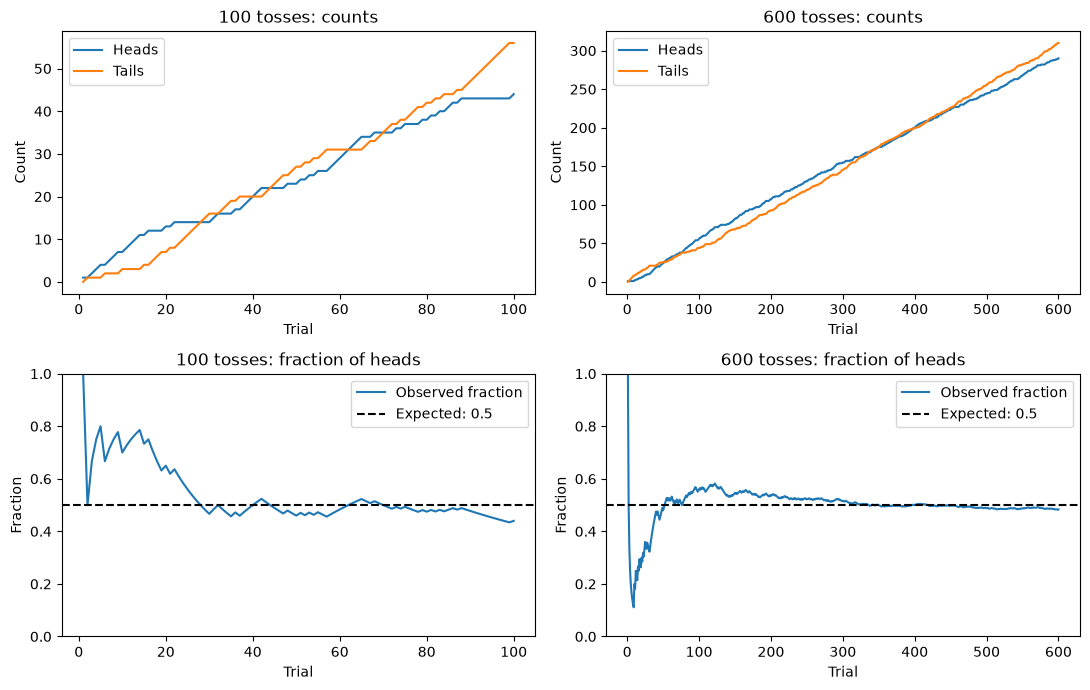

In [2]:
plt.figure(figsize=(11, 7))

for j, steps in enumerate([100, 600]):
    head_count = 0
    tail_count = 0
    heads = []
    tails = []
    prob_heads = []
    trial = []

    for step in range(steps):
        coin = np.random.randint(2)
        if coin == 0:
            head_count = head_count + 1
        else:
            tail_count = tail_count + 1

        heads.append(head_count)
        tails.append(tail_count)
        prob_heads.append(head_count / (step + 1))
        trial.append(step + 1)

    plt.subplot(2, 2, j + 1)
    plt.plot(trial, heads, label='Heads')
    plt.plot(trial, tails, label='Tails')
    plt.title(str(steps) + ' tosses: counts')
    plt.xlabel('Trial')
    plt.ylabel('Count')
    plt.legend()

    plt.subplot(2, 2, j + 3)
    plt.plot(trial, prob_heads, label='Observed fraction')
    plt.axhline(0.5, color='black', linestyle='--', label='Expected: 0.5')
    plt.title(str(steps) + ' tosses: fraction of heads')
    plt.xlabel('Trial')
    plt.ylabel('Fraction')
    plt.ylim(0, 1)
    plt.legend()

plt.tight_layout()
plt.show()


The fraction fluctuates strongly at first and generally settles closer to $0.5$ after more tosses. It does not have to move steadily toward $0.5$ on every trial.

## 2. A one-dimensional random walk

**Task.** Start at $x_0=0$. On each step move one unit left or right with equal probability, then plot the path. The array includes the initial position, so a walk of $N$ steps has $N+1$ positions.


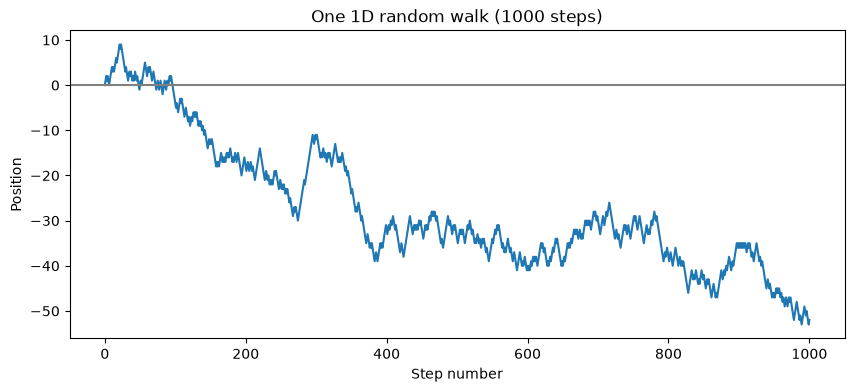

Final position after 1000 steps: -52


In [3]:
def walk_1d(steps):
    position = 0
    distance = [0]

    for step in range(steps):
        coin = np.random.randint(2)
        if coin == 0:
            position = position - 1
        else:
            position = position + 1
        distance.append(position)

    return distance

path = walk_1d(1000)
plt.figure(figsize=(10, 4))
plt.plot(range(len(path)), path)
plt.axhline(0, color='gray')
plt.xlabel('Step number')
plt.ylabel('Position')
plt.title('One 1D random walk (1000 steps)')
plt.show()
print('Final position after 1000 steps:', path[-1])


The path is one realization. Its final position can be far from zero even though left and right steps are equally likely.

## 3. Where did this walker spend its time?

**Task.** Count the positions visited *after* each step of the same path. Divide by the number of steps to obtain the fraction of observed times spent at each position. Then form the cumulative fraction $F(x)=P(X\leq x)$ for a position sampled from this path.

These figures describe **time occupancy for one walk**. They are not the distribution of final positions from independent walks.


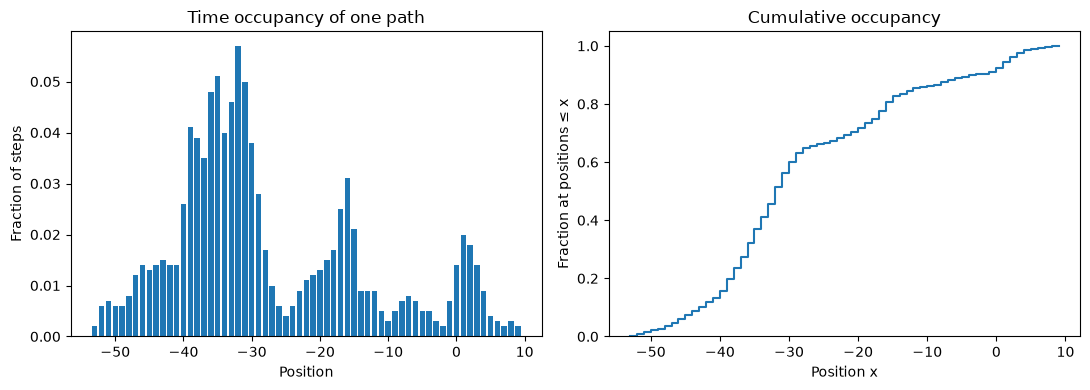

Sum of occupancy probabilities: 1.0
Last cumulative value: 1.0


In [4]:
visits = path[1:]
counted = Counter(visits)
positions = list(range(min(visits), max(visits) + 1))
occupancy = []
cumulative = []
prob_sum = 0

for position in positions:
    probability = counted[position] / len(visits)
    occupancy.append(probability)
    prob_sum = prob_sum + probability
    cumulative.append(prob_sum)

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.bar(positions, occupancy)
plt.xlabel('Position')
plt.ylabel('Fraction of steps')
plt.title('Time occupancy of one path')

plt.subplot(1, 2, 2)
plt.step(positions, cumulative, where='post')
plt.xlabel('Position x')
plt.ylabel('Fraction at positions ≤ x')
plt.title('Cumulative occupancy')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
print('Sum of occupancy probabilities:', round(sum(occupancy), 3))
print('Last cumulative value:', round(cumulative[-1], 3))


## 4. Many walks: endpoint distribution and spreading

**Task (extension).** Repeat the 1D walk many times. At each step measure the mean position and mean squared displacement $\langle x_N^2\rangle$. For independent fair unit steps, $\langle x_N\rangle=0$ and $\langle x_N^2\rangle=N$. Compare the simulated endpoint histogram with the expected spread $\sqrt{N}$.


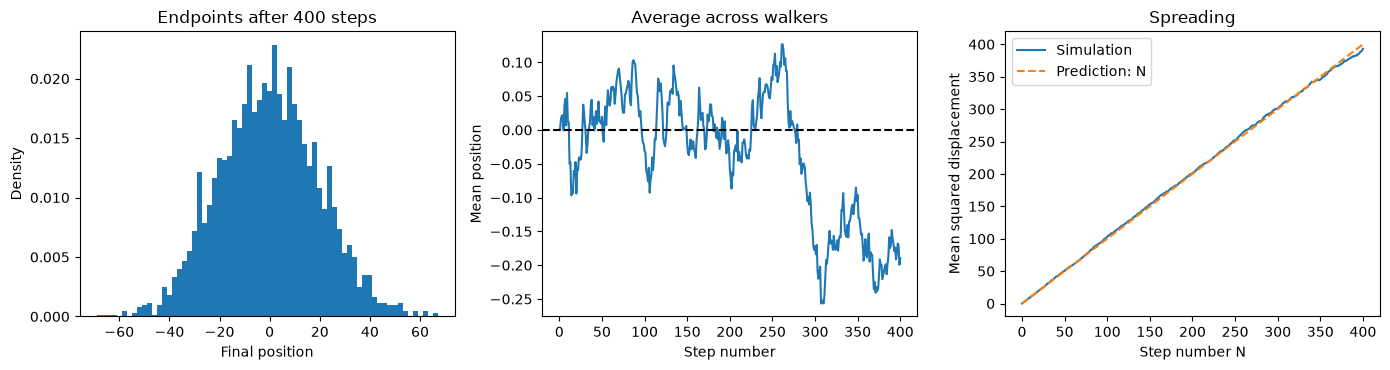

Endpoint mean: -0.19 ; expected 0
Endpoint standard deviation: 19.83 ; expected 20.0


In [11]:
number_of_walks = 3000
number_of_steps = 400
endpoints = []
mean_position = []
mean_square = []
all_walks = []

for walker in range(number_of_walks):
    one_walk = walk_1d(number_of_steps)
    all_walks.append(one_walk)
    endpoints.append(one_walk[-1])

for step in range(number_of_steps + 1):
    positions_at_step = []
    squared_positions = []
    for one_walk in all_walks:
        positions_at_step.append(one_walk[step])
        squared_positions.append(one_walk[step] ** 2)
    mean_position.append(np.mean(positions_at_step))
    mean_square.append(np.mean(squared_positions))

plt.figure(figsize=(14, 3.8))
plt.subplot(1, 3, 1)
# Accessible endpoints have the same parity as the step count.
endpoint_bins = np.arange(min(endpoints) - 1, max(endpoints) + 3, 2)
plt.hist(endpoints, bins=endpoint_bins, density=True)
plt.xlabel('Final position')
plt.ylabel('Density')
plt.title('Endpoints after 400 steps')

plt.subplot(1, 3, 2)
plt.plot(range(number_of_steps + 1), mean_position)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Step number')
plt.ylabel('Mean position')
plt.title('Average across walkers')

plt.subplot(1, 3, 3)
plt.plot(range(number_of_steps + 1), mean_square, label='Simulation')
plt.plot(range(number_of_steps + 1), range(number_of_steps + 1), '--', label='Prediction: N')
plt.xlabel('Step number N')
plt.ylabel('Mean squared displacement')
plt.title('Spreading')
plt.legend()
plt.tight_layout()
plt.show()
print('Endpoint mean:', round(np.mean(endpoints), 2), '; expected 0')
print('Endpoint standard deviation:', round(np.std(endpoints), 2), '; expected', round(np.sqrt(number_of_steps), 2))


Unlike time occupancy, the endpoint histogram counts **one final position per independent walker**. The average position is near zero while the walkers spread out; their mean squared displacement grows approximately linearly with the number of steps.

## 5. An unrestricted two-dimensional walk

**Task.** Choose left, right, down, or up with equal probability at every step. Plot the trajectory in the $xy$ plane.


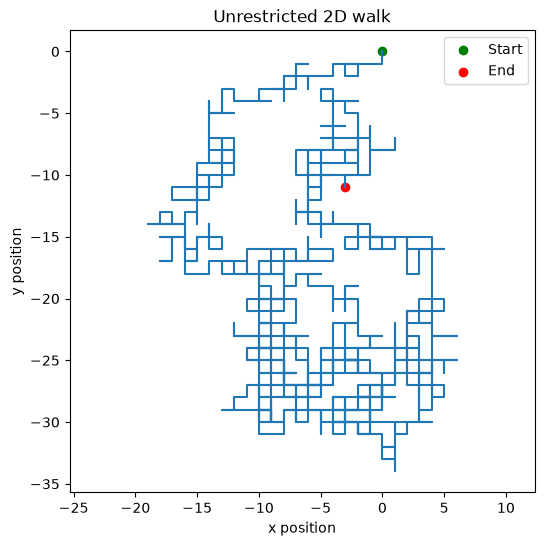

In [6]:
def walk_2d(steps, boundary=None):
    xpos = 0
    ypos = 0
    xdist = [0]
    ydist = [0]
    rejected = 0

    for step in range(steps):
        coin = np.random.randint(4)
        new_x = xpos
        new_y = ypos

        if coin == 0:
            new_x = xpos - 1
        elif coin == 1:
            new_x = xpos + 1
        elif coin == 2:
            new_y = ypos + 1
        else:
            new_y = ypos - 1

        if boundary is not None and (abs(new_x) > boundary or abs(new_y) > boundary):
            rejected = rejected + 1
        else:
            xpos = new_x
            ypos = new_y

        xdist.append(xpos)
        ydist.append(ypos)

    return xdist, ydist, rejected

xpos, ypos, rejected = walk_2d(1000)
plt.figure(figsize=(6, 6))
plt.plot(xpos, ypos)
plt.scatter(xpos[0], ypos[0], color='green', label='Start')
plt.scatter(xpos[-1], ypos[-1], color='red', label='End')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Unrestricted 2D walk')
plt.axis('equal')
plt.legend()
plt.show()


## 6. A walk confined to a square

**Task.** Repeat the 2D walk inside $-10\leq x,y\leq10$. If a proposed step would leave the square, keep the walker at its current position for that step. This matches the boundary rule in the original exercise.


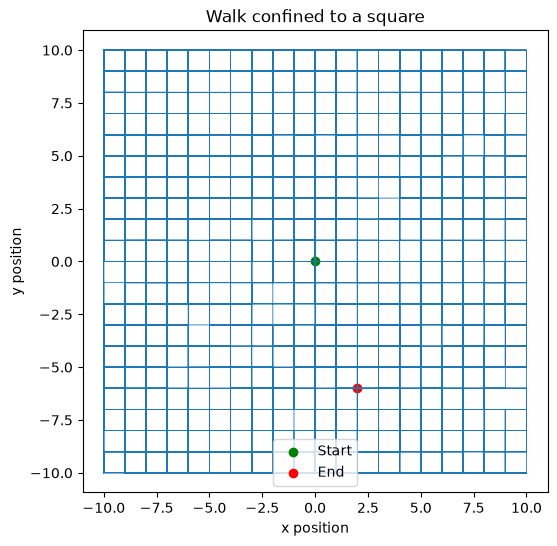

Fraction of proposed steps rejected at boundary: 0.052


In [7]:
xpos, ypos, rejected = walk_2d(10000, boundary=10)
plt.figure(figsize=(6, 6))
plt.plot(xpos, ypos, linewidth=0.6)
plt.scatter(xpos[0], ypos[0], color='green', label='Start')
plt.scatter(xpos[-1], ypos[-1], color='red', label='End')
plt.xlim(-10.5, 10.5)
plt.ylim(-10.5, 10.5)
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Walk confined to a square')
plt.axis('equal')
plt.legend()
plt.show()
print('Fraction of proposed steps rejected at boundary:', round(rejected / 10000, 3))


The walker can revisit a boundary many times; a rejected outward step contributes a stationary step. Changing the boundary rule (for example, bouncing inward) would define a different model.

## What these exercises show

- A fair coin produces unbiased steps, but any single walk remains irregular.
- Time occupancy along a path and endpoint probability across walkers answer different questions.
- Averaging independent walks reveals the predicted $\langle x_N^2\rangle=N$ trend.
- Boundary conditions matter: the confined walker occasionally stays still when an outward move is proposed.

*Compilation original Mathematical Methods for Physicists II notebooks including assignment and quiz tasks pertatining to probability and random walk.*
